In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("ToyotaCorolla - MLR.csv")

print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nSummary Statistics:\n", df.describe())
print("\nMissing Values:\n", df.isnull().sum())

Shape: (1436, 11)

Data Types:
 Price         int64
Age_08_04     int64
KM            int64
Fuel_Type    object
HP            int64
Automatic     int64
cc            int64
Doors         int64
Cylinders     int64
Gears         int64
Weight        int64
dtype: object

Summary Statistics:
               Price    Age_08_04             KM           HP    Automatic  \
count   1436.000000  1436.000000    1436.000000  1436.000000  1436.000000   
mean   10730.824513    55.947075   68533.259749   101.502089     0.055710   
std     3626.964585    18.599988   37506.448872    14.981080     0.229441   
min     4350.000000     1.000000       1.000000    69.000000     0.000000   
25%     8450.000000    44.000000   43000.000000    90.000000     0.000000   
50%     9900.000000    61.000000   63389.500000   110.000000     0.000000   
75%    11950.000000    70.000000   87020.750000   110.000000     0.000000   
max    32500.000000    80.000000  243000.000000   192.000000     1.000000   

                cc

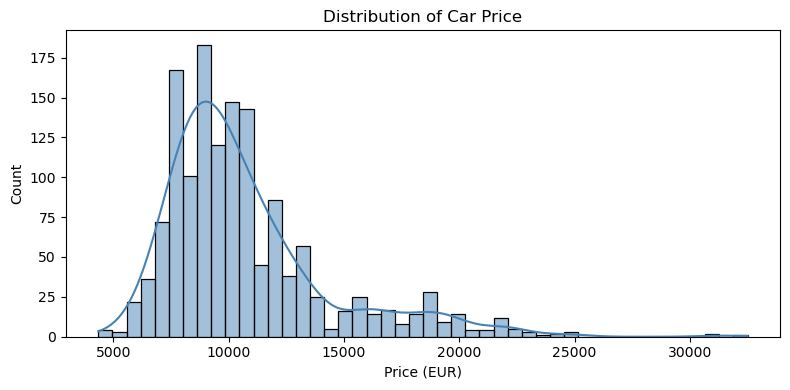

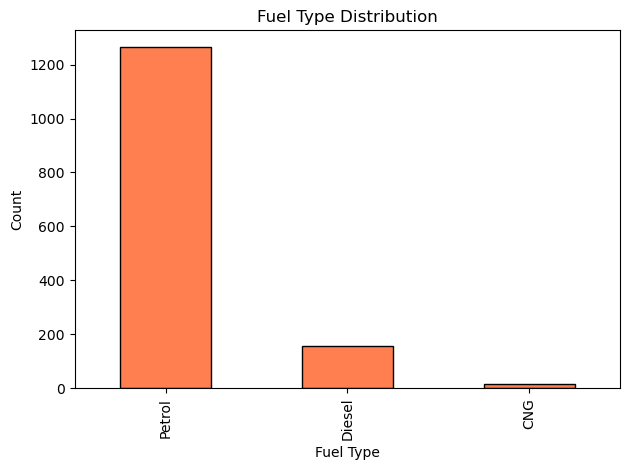

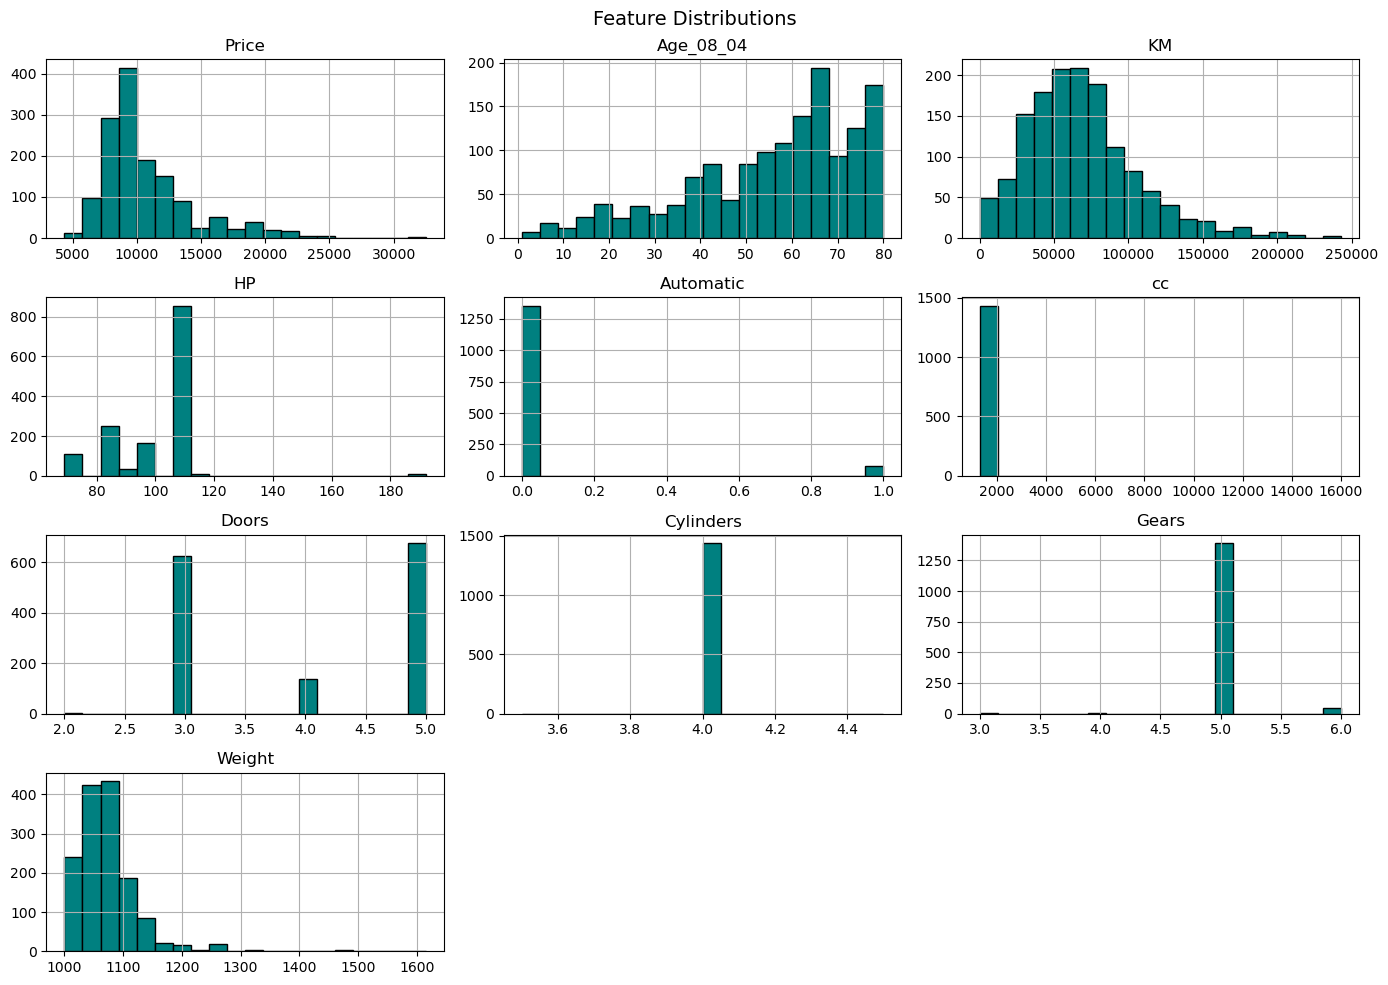

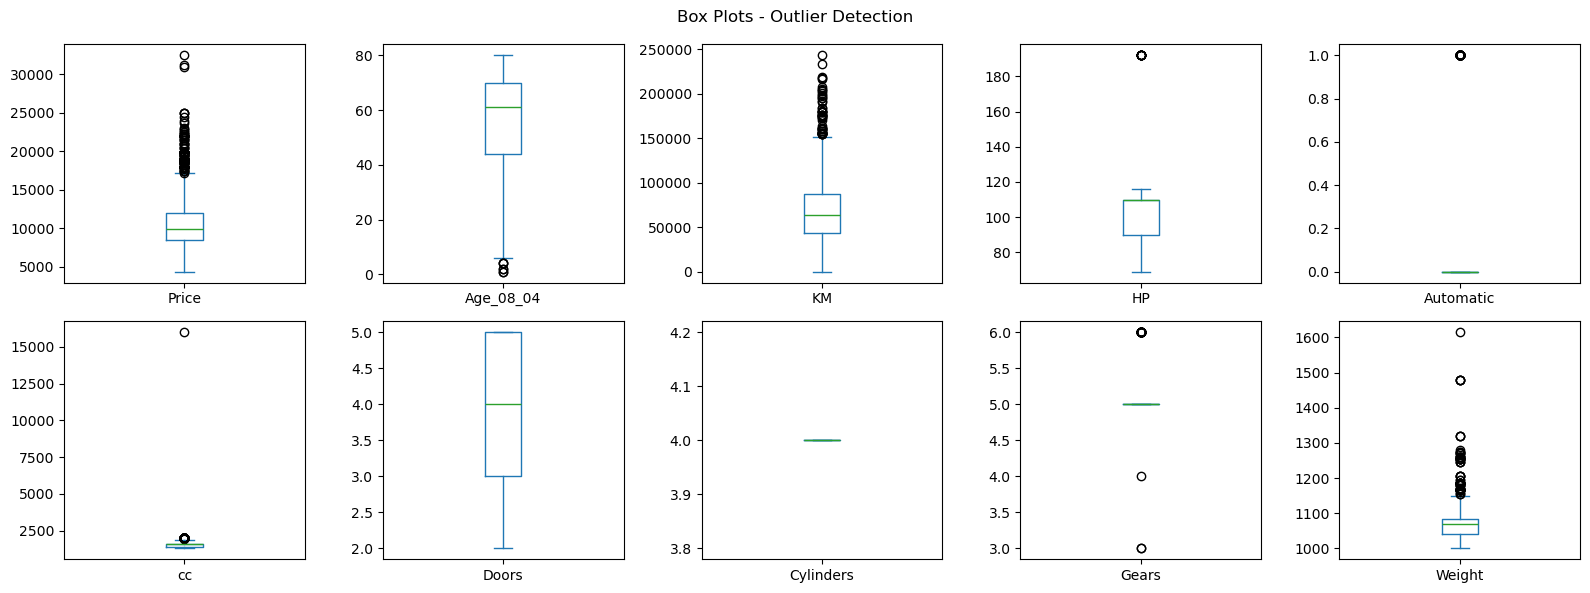

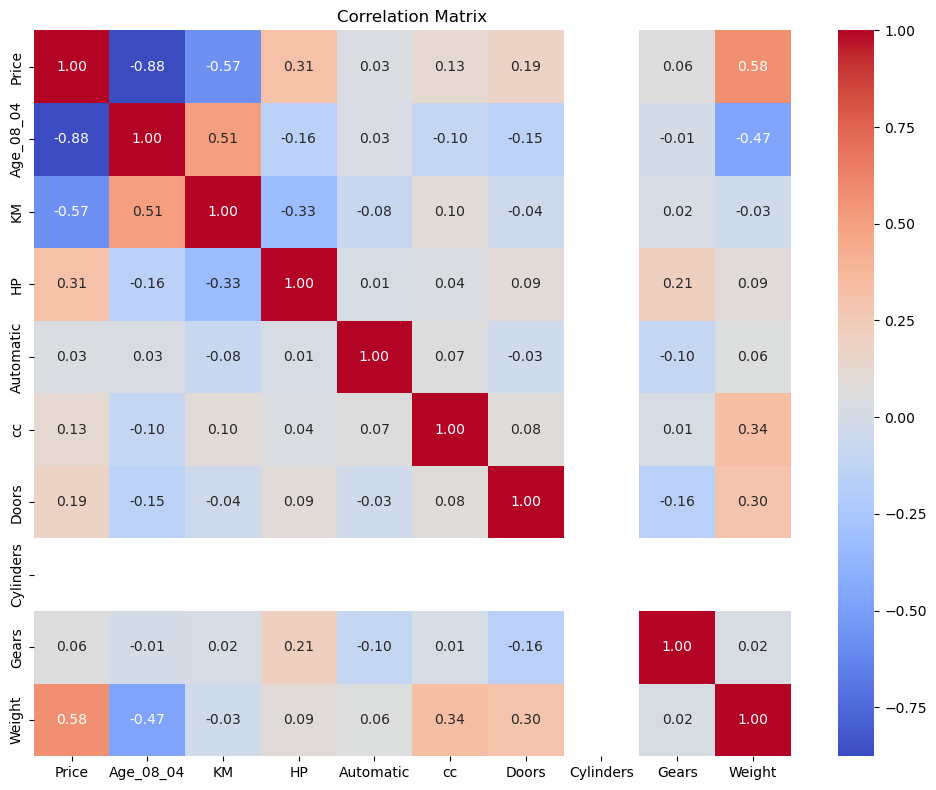

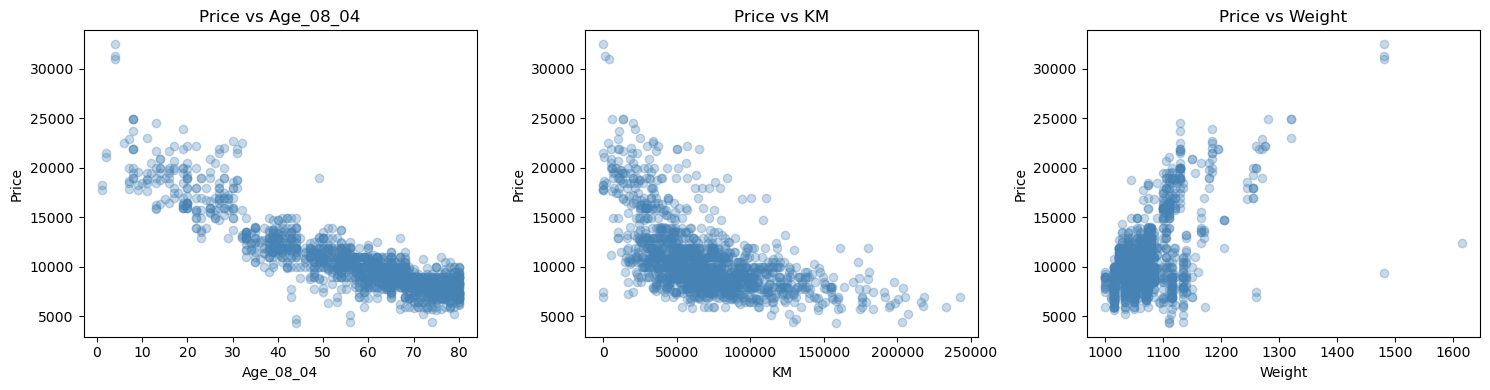

In [2]:
# Distribution of Target Variable (Price)
plt.figure(figsize=(8, 4))
sns.histplot(df['Price'], kde=True, color='steelblue')
plt.title('Distribution of Car Price')
plt.xlabel('Price (EUR)')
plt.tight_layout()
plt.show()

# Count of Fuel Types
df['Fuel_Type'].value_counts().plot(kind='bar', color='coral', edgecolor='black')
plt.title('Fuel Type Distribution')
plt.xlabel('Fuel Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Histograms for all numeric features
df.hist(figsize=(14, 10), bins=20, color='teal', edgecolor='black')
plt.suptitle('Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

# Box plots for outlier detection
numeric_cols = df.select_dtypes(include='number').columns
df[numeric_cols].plot(kind='box', subplots=True, figsize=(16, 6), layout=(2, 5))
plt.suptitle('Box Plots - Outlier Detection')
plt.tight_layout()
plt.show()

# Correlation Heatmap (numeric only)
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

# Scatter plots: Price vs key features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Age_08_04', 'KM', 'Weight']):
    ax.scatter(df[col], df['Price'], alpha=0.3, color='steelblue')
    ax.set_xlabel(col)
    ax.set_ylabel('Price')
    ax.set_title(f'Price vs {col}')
plt.tight_layout()
plt.show()

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df_clean = df.copy()

# One-Hot Encode Fuel_Type (drop first to avoid dummy variable trap)
df_clean = pd.get_dummies(df_clean, columns=['Fuel_Type'], drop_first=True)

# Features and Target
X = df_clean.drop(columns=['Price'])
y = df_clean['Price']

# 80-20 Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize features (needed for Lasso/Ridge)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)
print("Features  :", list(X.columns))

Train size: (1148, 11)
Test size : (288, 11)
Features  : ['Age_08_04', 'KM', 'HP', 'Automatic', 'cc', 'Doors', 'Cylinders', 'Gears', 'Weight', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol']


In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(name, y_test, y_pred):
    mae  = mean_absolute_error(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, y_pred)
    print(f"\n--- {name} ---")
    print(f"MAE  : {mae:.2f}")
    print(f"MSE  : {mse:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.4f}")
    return r2

In [5]:
# ── Model 1: All Features ──────────────────────────────────────────
model1 = LinearRegression()
model1.fit(X_train, y_train)
y_pred1 = model1.predict(X_test)
r2_1 = evaluate("Model 1: All Features", y_test, y_pred1)

# Coefficients
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model1.coef_})
print("\nCoefficients:\n", coef_df.sort_values('Coefficient', key=abs, ascending=False))


--- Model 1: All Features ---
MAE  : 990.89
MSE  : 2203043.82
RMSE : 1484.27
R²   : 0.8349

Coefficients:
              Feature   Coefficient
10  Fuel_Type_Petrol  1.370809e+03
7              Gears  5.516007e+02
3          Automatic  1.488309e+02
0          Age_08_04 -1.208305e+02
9   Fuel_Type_Diesel -6.854876e+01
5              Doors -6.031097e+01
8             Weight  2.588496e+01
2                 HP  1.403948e+01
4                 cc -3.037219e-02
1                 KM -1.623141e-02
6          Cylinders -1.108447e-12


In [6]:
# ── Model 2: Selected Features (high-correlation ones) ────────────
selected_features = ['Age_08_04', 'KM', 'HP', 'Weight', 'cc',
                     'Fuel_Type_Diesel', 'Fuel_Type_Petrol']
# Keep only columns that exist after encoding
selected_features = [c for c in selected_features if c in X.columns]

model2 = LinearRegression()
model2.fit(X_train[selected_features], y_train)
y_pred2 = model2.predict(X_test[selected_features])
r2_2 = evaluate("Model 2: Selected Features", y_test, y_pred2)


--- Model 2: Selected Features ---
MAE  : 1000.87
MSE  : 2215881.46
RMSE : 1488.58
R²   : 0.8339


In [7]:
# ── Model 3: Log-Transformed Target ───────────────────────────────
# Log transform reduces skewness in Price
y_train_log = np.log(y_train)
model3 = LinearRegression()
model3.fit(X_train, y_train_log)
y_pred3_log = model3.predict(X_test)
y_pred3 = np.exp(y_pred3_log)   # back-transform to original scale
r2_3 = evaluate("Model 3: Log-Transformed Target", y_test, y_pred3)


--- Model 3: Log-Transformed Target ---
MAE  : 863.00
MSE  : 1581808.02
RMSE : 1257.70
R²   : 0.8814


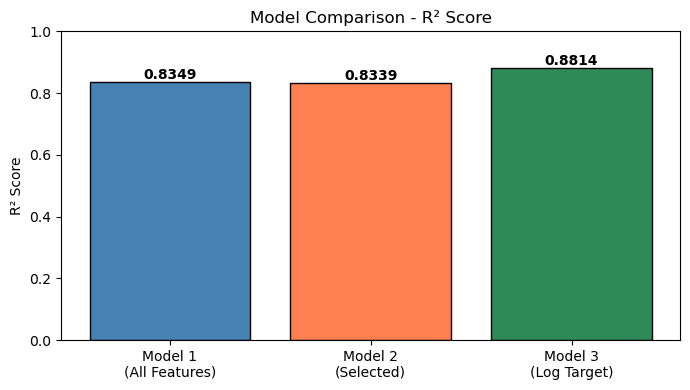

In [8]:
# Compare all 3 models visually
models = ['Model 1\n(All Features)', 'Model 2\n(Selected)', 'Model 3\n(Log Target)']
r2_scores = [r2_1, r2_2, r2_3]

plt.figure(figsize=(7, 4))
plt.bar(models, r2_scores, color=['steelblue', 'coral', 'seagreen'], edgecolor='black')
plt.ylim(0, 1)
plt.ylabel('R² Score')
plt.title('Model Comparison - R² Score')
for i, v in enumerate(r2_scores):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

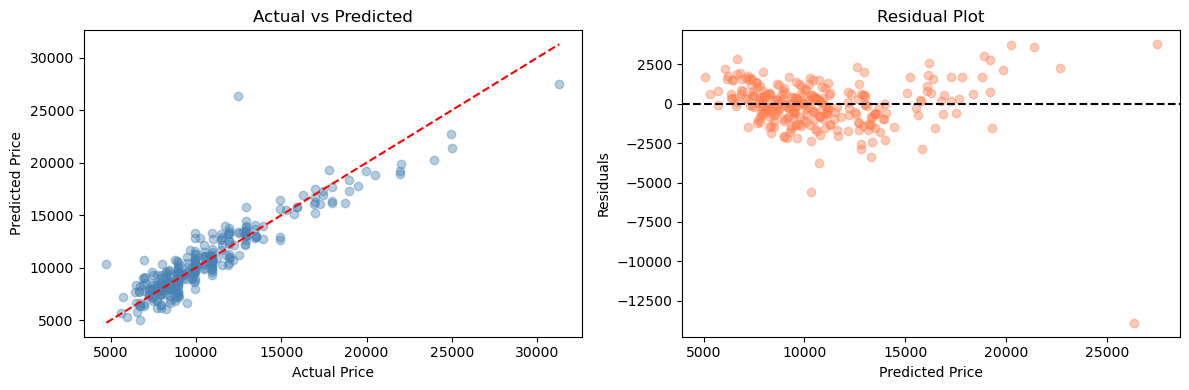

In [9]:
# Residual plot for best model (Model 1 typically)
best_pred = y_pred1  # change to y_pred2 or y_pred3 if they score better

residuals = y_test - best_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Actual vs Predicted
axes[0].scatter(y_test, best_pred, alpha=0.4, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].set_title('Actual vs Predicted')

# Residuals
axes[1].scatter(best_pred, residuals, alpha=0.4, color='coral')
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_xlabel('Predicted Price')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()

In [10]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import cross_val_score

# ── Ridge Regression ──────────────────────────────────────────────
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)
evaluate("Ridge Regression (alpha=1.0)", y_test, y_pred_ridge)

# ── Lasso Regression ──────────────────────────────────────────────
lasso = Lasso(alpha=50, max_iter=10000)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)
evaluate("Lasso Regression (alpha=50)", y_test, y_pred_lasso)

# Lasso feature selection — coefficients driven to zero
lasso_coef = pd.DataFrame({
    'Feature': X.columns,
    'Lasso Coefficient': lasso.coef_
})
print("\nLasso Coefficients (0 = feature eliminated):")
print(lasso_coef.sort_values('Lasso Coefficient', key=abs, ascending=False))


--- Ridge Regression (alpha=1.0) ---
MAE  : 990.86
MSE  : 2200942.87
RMSE : 1483.56
R²   : 0.8350

--- Lasso Regression (alpha=50) ---
MAE  : 994.23
MSE  : 2100363.63
RMSE : 1449.26
R²   : 0.8426

Lasso Coefficients (0 = feature eliminated):
             Feature  Lasso Coefficient
0          Age_08_04       -2252.726439
8             Weight        1149.762500
1                 KM        -634.232429
10  Fuel_Type_Petrol         307.034044
2                 HP         252.300211
7              Gears          69.894602
3          Automatic           2.239938
4                 cc          -0.000000
5              Doors          -0.000000
6          Cylinders           0.000000
9   Fuel_Type_Diesel          -0.000000


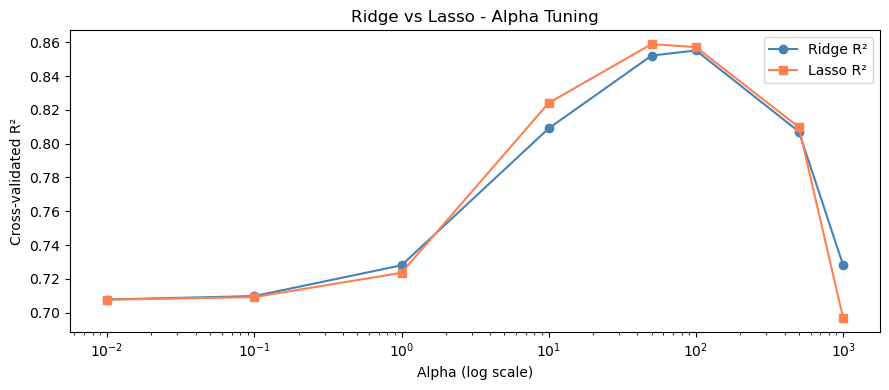

Best Ridge alpha: 100
Best Lasso alpha: 50


In [11]:
# Tune alpha with cross-validation
alphas = [0.01, 0.1, 1, 10, 50, 100, 500, 1000]

ridge_scores, lasso_scores = [], []
for a in alphas:
    r = Ridge(alpha=a)
    l = Lasso(alpha=a, max_iter=10000)
    ridge_scores.append(cross_val_score(r, X_train_scaled, y_train, cv=5, scoring='r2').mean())
    lasso_scores.append(cross_val_score(l, X_train_scaled, y_train, cv=5, scoring='r2').mean())

plt.figure(figsize=(9, 4))
plt.plot(alphas, ridge_scores, marker='o', label='Ridge R²', color='steelblue')
plt.plot(alphas, lasso_scores, marker='s', label='Lasso R²', color='coral')
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Cross-validated R²')
plt.title('Ridge vs Lasso - Alpha Tuning')
plt.legend()
plt.tight_layout()
plt.show()

print("Best Ridge alpha:", alphas[np.argmax(ridge_scores)])
print("Best Lasso alpha:", alphas[np.argmax(lasso_scores)])